# Hierarchical Clustering

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv("/content/CC GENERAL.csv")

In [3]:
dataset.shape

(8950, 18)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
X = dataset.iloc[:,[3,4]].values

In [6]:
print(X)

[[  95.4     0.  ]
 [   0.      0.  ]
 [ 773.17  773.17]
 ...
 [ 144.4     0.  ]
 [   0.      0.  ]
 [1093.25 1093.25]]


### Using the dendrogram to find the optimal number of clusters

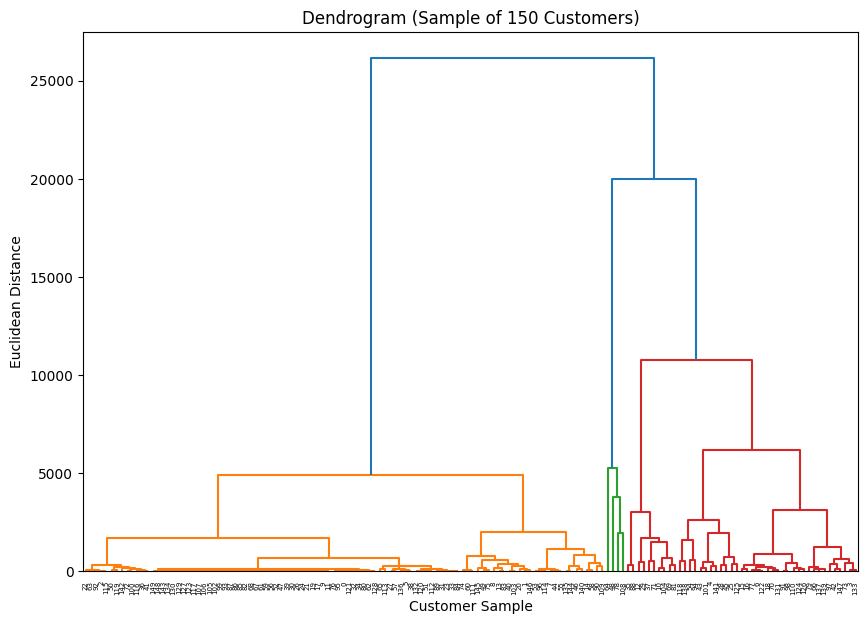

In [10]:
import scipy.cluster.hierarchy as sch
np.random.seed(42)
sample_idx = np.random.choice(X.shape[0], size=150, replace=False)
X_sample = X[sample_idx]

plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X_sample, method='ward'))
plt.title("Dendrogram (Sample of 150 Customers)")
plt.xlabel("Customer Sample")
plt.ylabel("Euclidean Distance")
plt.show()

## Training the Hierarchical Clustering model on the dataset

In [11]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering (n_clusters = 5, linkage = 'ward')
y_hc = hc.fit_predict(X)

In [12]:
print(y_hc)

[1 1 1 ... 1 1 4]


## Visualising the clusters

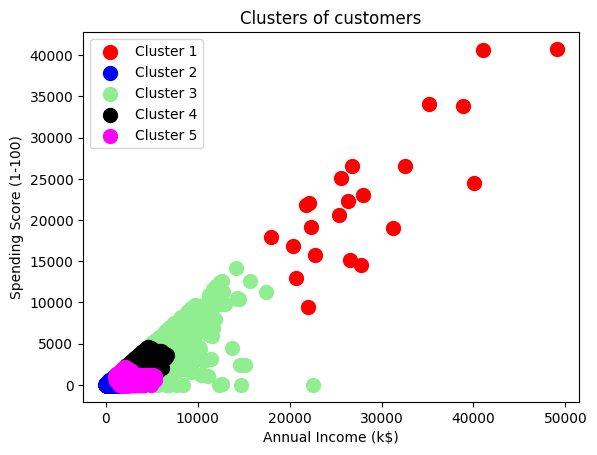

In [13]:
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'lightgreen', label = 'Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'black', label = 'Cluster 4')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## Internal Evaluation of Cluster
### DB Score (lower is better)

In [14]:
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(X,y_hc)

np.float64(0.6901922253411705)

## External Evaluation
### Homogenity Score (higher is better)

In [17]:
from sklearn.cluster import AgglomerativeClustering

# Fit the model and get cluster assignments
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc = hc.fit_predict(X)

# y_hc now contains the cluster labels for each sample in X
print(y_hc)

[1 1 1 ... 1 1 4]
